# Myanmar Wikipedia Control Map — Ground Truth Label Extraction

Parses territorial control labels directly from Wikipedia SVG files.
**No system dependencies** — built-in Python + standard data science stack only.

**How to get the SVG files:**
1. Go to https://commons.wikimedia.org/wiki/File:Myanmar_civil_war.svg
2. In the file history table, click each date you want
3. Right-click the page → Save Page As → save as `myanmar_YYYY-MM-DD.svg`
4. Put files in `data/raw/wikipedia_snapshots/`

**Output:** `data/processed/myanmar_control_labels.csv`


In [5]:
import xml.etree.ElementTree as ET
import re
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

REPO_ROOT     = Path('..').resolve()
SNAPSHOTS_DIR = REPO_ROOT / 'data' / 'raw' / 'wikipedia_snapshots'
OUTPUT_CSV    = REPO_ROOT / 'data' / 'processed' / 'myanmar_control_labels.csv'
GADM_PATH     = REPO_ROOT / 'data' / 'raw' / 'gadm'

SNAPSHOTS_DIR.mkdir(parents=True, exist_ok=True)
(REPO_ROOT / 'data' / 'processed').mkdir(parents=True, exist_ok=True)
print("Ready")


Ready


## Color map — pre-filled from SVG analysis

In [6]:
# Colors extracted directly from the Wikipedia SVG file.
# Identified by cross-referencing hex codes with geographic positions
# and the Wikipedia legend (Tatmadaw=salmon, PDF=light green,
# Karen=blue, Arakan Army=yellow, KIA=bright green, etc.)
#
# Format: '#hex' -> (actor_name, broad_category)
# broad_category: 'Junta' | 'Resistance' | 'Contested' | 'Autonomous' | 'Other'

COLOR_MAP = {
    # ── Tatmadaw / SAC (salmon-pink tones, central Myanmar) ──────────────────
    '#ebc0b3': ('Tatmadaw',           'Junta'),   # 42 paths — dominant Junta color
    '#ebbfb2': ('Tatmadaw',           'Junta'),
    '#ebbeb2': ('Tatmadaw',           'Junta'),
    '#ebc0b2': ('Tatmadaw',           'Junta'),
    '#cf959c': ('Tatmadaw',           'Junta'),   # darker variant, SE Myanmar
    '#ed9595': ('Tatmadaw',           'Junta'),
    '#cd7c7c': ('Tatmadaw',           'Junta'),
    '#f59bab': ('Tatmadaw',           'Junta'),   # N Myanmar
    '#70333a': ('Tatmadaw',           'Junta'),   # dark red variant

    # ── Contested / active frontline (bright red) ────────────────────────────
    '#ff0000': ('Contested',          'Contested'),  # 34 paths
    '#d64a4a': ('Contested',          'Contested'),
    '#ff7f2a': ('Contested',          'Contested'),

    # ── PDF / NUG (light greens, central/Sagaing) ────────────────────────────
    '#cae7c4': ('PDF',                'Resistance'),  # 31 paths — dominant PDF color
    '#a9e89b': ('PDF',                'Resistance'),

    # ── Kachin Independence Army (bright greens, N Myanmar) ──────────────────
    '#cceadd': ('Kachin Independence Army', 'Resistance'),  # N Kachin
    '#6bc681': ('Kachin Independence Army', 'Resistance'),
    '#23c500': ('Kachin Independence Army', 'Resistance'),

    # ── Karen resistance (blues, E Myanmar / Karen State) ────────────────────
    '#88c0f2': ('Karen resistance',   'Resistance'),  # 11 paths — Karen State
    '#c6ecff': ('Karen resistance',   'Resistance'),  # 16 paths — lighter blue
    '#1677cd': ('Karen resistance',   'Resistance'),

    # ── Arakan Army (yellows, Rakhine State) ─────────────────────────────────
    '#f3eba5': ('Arakan Army',        'Resistance'),  # 13 paths — main AA color
    '#e2e261': ('Arakan Army',        'Resistance'),
    '#dfca08': ('Arakan Army',        'Resistance'),

    # ── Chin / Rakhine coast forces (bright greens at coast) ─────────────────
    '#45eb22': ('Chin National Army', 'Resistance'),  # 14 paths — Chin/Rakhine
    '#4db689': ('Chin Brotherhood',   'Resistance'),
    '#c1e745': ('Chin Brotherhood',   'Resistance'),

    # ── MNDAA / TNLA (orange, N Shan) ────────────────────────────────────────
    '#e56044': ('MNDAA',              'Resistance'),

    # ── Mon Liberation Army (teals, Mon State / S Myanmar) ───────────────────
    '#86decc': ('Mon Liberation Army','Resistance'),   # 7 paths
    '#00c0c0': ('Mon Liberation Army','Resistance'),
    '#96efef': ('Mon Liberation Army','Resistance'),

    # ── Pa-O NLA (purples, S Shan State) ─────────────────────────────────────
    '#a690df': ('Pa-O NLA',           'Resistance'),
    '#a598d7': ('Pa-O NLA',           'Resistance'),
    '#c5bdc7': ('Pa-O NLA',           'Resistance'),

    # ── Pink/magenta tones ────────────────────────────────────────────────────
    '#e899b7': ('Karenni resistance', 'Resistance'),  # 5 paths — Kayah State
    '#f289e3': ('Danu forces',        'Resistance'),

    # ── SSA-North / non-combatant (grey-green, N Shan) ───────────────────────
    '#b8b8ab': ('SSA-North',          'Autonomous'),  # 7 paths
    '#bbbba8': ('SSA-North',          'Autonomous'),
    '#8d9591': ('SSA-South',          'Autonomous'),

    # ── UWSA (grey-green, E Shan State) ──────────────────────────────────────
    '#ccd7d2': ('UWSA',               'Other'),       # 7 paths — Wa State
    '#b79d9d': ('UWSA',               'Other'),
}

print(f"Color map: {len(COLOR_MAP)} colors defined")
cats = Counter(v[1] for v in COLOR_MAP.values())
for cat, n in sorted(cats.items()):
    print(f"  {cat:12s}: {n} colors")


Color map: 40 colors defined
  Autonomous  : 3 colors
  Contested   : 3 colors
  Junta       : 9 colors
  Other       : 2 colors
  Resistance  : 23 colors


## SVG parsing

In [7]:
# Myanmar SVG coordinate system
MMR = {
    'lon_min': 92.17, 'lon_max': 101.17,
    'lat_min':  9.78, 'lat_max':  28.55,
    'svg_w':   1228,  'svg_h':   2003,
}

def find_all_tag(root, tag):
    return [c for c in root.iter() if c.tag.split('}')[-1] == tag]

def get_fill(p):
    style = p.get('style', '')
    fill  = p.get('fill', '')
    if 'fill:' in style:
        m = re.search(r'fill:\s*([^;"\s]+)', style)
        if m: fill = m.group(1)
    return fill.lower().strip() if fill else None

def first_moveto(d):
    m = re.match(r'\s*[Mm]\s*([-+]?\d*\.?\d+)[,\s]+([-+]?\d*\.?\d+)', d)
    if m: return float(m.group(1)), float(m.group(2))
    return None, None

def svg_to_lonlat(sx, sy):
    lon = MMR['lon_min'] + (sx / MMR['svg_w']) * (MMR['lon_max'] - MMR['lon_min'])
    lat = MMR['lat_max'] - (sy / MMR['svg_h']) * (MMR['lat_max'] - MMR['lat_min'])
    return lon, lat

def hex2rgb(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))

def closest_color(fill, color_map, tolerance=18):
    try:
        rgb = hex2rgb(fill)
    except:
        return 'Unknown', 'Unknown'
    # Exact match first
    if fill in color_map:
        return color_map[fill]
    # Nearest neighbor
    best_label, best_cat, best_d = 'Unknown', 'Unknown', float('inf')
    for ref_hex, (label, cat) in color_map.items():
        ref = hex2rgb(ref_hex)
        d   = sum((a-b)**2 for a,b in zip(rgb, ref)) ** 0.5
        if d < best_d:
            best_d, best_label, best_cat = d, label, cat
    return (best_label, best_cat) if best_d <= tolerance else ('Unknown', 'Unknown')

def parse_svg(svg_path):
    tree  = ET.parse(str(svg_path))
    root  = tree.getroot()
    recs  = []
    for p in find_all_tag(root, 'path'):
        fill = get_fill(p)
        if not fill or fill == 'none': continue
        sx, sy = first_moveto(p.get('d', ''))
        if sx is None: continue
        lon, lat = svg_to_lonlat(sx, sy)
        if not (MMR['lon_min'] <= lon <= MMR['lon_max'] and
                MMR['lat_min'] <= lat <= MMR['lat_max']): continue
        actor, cat = closest_color(fill, COLOR_MAP)
        recs.append({'lon': lon, 'lat': lat,
                     'fill': fill, 'actor': actor, 'control_broad': cat})
    return recs

print("Parsing functions defined")


Parsing functions defined


## Load GADM township boundaries

In [ ]:
gdf = gpd.read_file(GADM_PATH / 'gadm41_MMR.gpkg', layer='ADM_ADM_3')
gdf = gdf.loc[:, ~gdf.columns.duplicated()].copy()  # add this line

col_map = {}
for col in gdf.columns:
    if 'NAME_3' in col: col_map[col] = 'township'
    elif 'NAME_2' in col: col_map[col] = 'district'
    elif 'NAME_1' in col: col_map[col] = 'state_region'
gdf = gdf.rename(columns=col_map).to_crs('EPSG:4326')
print(f"Loaded {len(gdf)} townships")

Loaded 286 townships


## Process all SVG snapshots → CSV

In [10]:
# List your saved SVG files
EXPECTED_DATES = [
    '2023-12-30',
    '2024-01-09',
    '2024-04-04',
    '2024-08-09',
    '2024-11-10',
    '2025-01-05',
    '2025-04-04',
]

print("SVG snapshot status:")
available = []
for date in EXPECTED_DATES:
    p = SNAPSHOTS_DIR / f'myanmar_{date}.svg'
    status = '✓' if p.exists() else '✗ missing — save from Wikimedia file history'
    print(f"  {status}  myanmar_{date}.svg")
    if p.exists():
        available.append((date, p))

print(f"\nReady: {len(available)} / {len(EXPECTED_DATES)}")


SVG snapshot status:
  ✓  myanmar_2023-12-30.svg
  ✓  myanmar_2024-01-09.svg
  ✓  myanmar_2024-04-04.svg
  ✓  myanmar_2024-08-09.svg
  ✓  myanmar_2024-11-10.svg
  ✓  myanmar_2025-01-05.svg
  ✓  myanmar_2025-04-04.svg

Ready: 7 / 7


In [17]:
# Fix gdf duplicate columns ONCE before the loop
gdf = gdf.loc[:, ~gdf.columns.duplicated()].copy()

if gdf is not None and available:
    all_records = []
    for date, svg_path in available:
        print(f"{date}...", end=' ', flush=True)
        recs    = parse_svg(svg_path)
        twp_map = assign_to_townships(recs, gdf)
        for _, row in gdf.iterrows():
            twp  = row['township']
            ctrl = twp_map.get(twp, {'actor':'Unknown','control_broad':'Unknown','n_signals':0})
            all_records.append({
                'date':          date,
                'township':      twp,
                'state_region':  row.get('state_region', ''),
                'district':      row.get('district', ''),
                'control':       ctrl['actor'],
                'control_broad': ctrl['control_broad'],
                'n_signals':     ctrl['n_signals'],
            })
        cats = Counter(r['control_broad'] for r in all_records if r['date']==date)
        print({k:v for k,v in sorted(cats.items())})

    labels_df = pd.DataFrame(all_records)
    labels_df.to_csv(OUTPUT_CSV, index=False)
    print(f"\n✓ Saved {len(labels_df):,} records to {OUTPUT_CSV}")
    print(labels_df['control_broad'].value_counts())
def assign_to_townships(svg_records, gdf):
    if not svg_records or gdf is None:
        return {}
    pts = gpd.GeoDataFrame(svg_records,
            geometry=[Point(r['lon'], r['lat']) for r in svg_records],
            crs='EPSG:4326')

    # Fix duplicate columns in gdf first
    gdf_clean = gdf.loc[:, ~gdf.columns.duplicated()].copy()
    gdf_clean = gdf_clean[['township', 'geometry']].rename(columns={'township': 'twp'})

    joined = gpd.sjoin(pts, gdf_clean, how='left', predicate='within')

    result = {}
    for twp, grp in joined.groupby('twp'):
        actors = grp['actor'].dropna()
        cats   = grp['control_broad'].dropna()
        if len(actors) == 0: continue
        result[twp] = {
            'actor':         Counter(actors).most_common(1)[0][0],
            'control_broad': Counter(cats).most_common(1)[0][0],
            'n_signals':     len(actors),
        }
    return result

# ── Run ───────────────────────────────────────────────────────────────────────
if gdf is not None and available:
    all_records = []
    for date, svg_path in available:
        print(f"{date}...", end=' ', flush=True)
        recs    = parse_svg(svg_path)
        twp_map = assign_to_townships(recs, gdf)
        for _, row in gdf.iterrows():
            twp  = row.get('township', '')
            ctrl = twp_map.get(twp, {'actor':'Unknown','control_broad':'Unknown','n_signals':0})
            all_records.append({
                'date':          date,
                'township':      twp,
                'state_region':  row.get('state_region', ''),
                'district':      row.get('district', ''),
                'control':       ctrl['actor'],
                'control_broad': ctrl['control_broad'],
                'n_signals':     ctrl['n_signals'],
            })
        cats = Counter(r['control_broad'] for r in all_records if r['date']==date)
        print({k:v for k,v in sorted(cats.items())})

    labels_df = pd.DataFrame(all_records)
    labels_df.to_csv(OUTPUT_CSV, index=False)
    print(f"\n✓ Saved {len(labels_df):,} records to {OUTPUT_CSV}")
    print(labels_df['control_broad'].value_counts())
else:
    print("Add SVG files and/or load GADM first")


2023-12-30... {'Contested': 1, 'Junta': 4, 'Resistance': 7, 'Unknown': 274}
2024-01-09... {'Contested': 1, 'Junta': 3, 'Resistance': 16, 'Unknown': 266}
2024-04-04... {'Contested': 1, 'Junta': 17, 'Resistance': 30, 'Unknown': 238}
2024-08-09... {'Contested': 1, 'Junta': 22, 'Resistance': 38, 'Unknown': 225}
2024-11-10... {'Junta': 27, 'Resistance': 42, 'Unknown': 217}
2025-01-05... {'Junta': 28, 'Resistance': 49, 'Unknown': 209}
2025-04-04... {'Junta': 28, 'Resistance': 53, 'Unknown': 205}

✓ Saved 2,002 records to C:\Users\corne\OneDrive\Nuttige dingen\Verder studeren Spanje\BSE\LEERSTOF\Term3\Thesis\territorial_control_dsdm_master_project\data\processed\myanmar_control_labels.csv
control_broad
Unknown       1634
Resistance     235
Junta          129
Contested        4
Name: count, dtype: int64
2023-12-30... {'Contested': 1, 'Junta': 4, 'Resistance': 7, 'Unknown': 274}
2024-01-09... {'Contested': 1, 'Junta': 3, 'Resistance': 16, 'Unknown': 266}
2024-04-04... {'Contested': 1, 'Junta': 

## Visualize

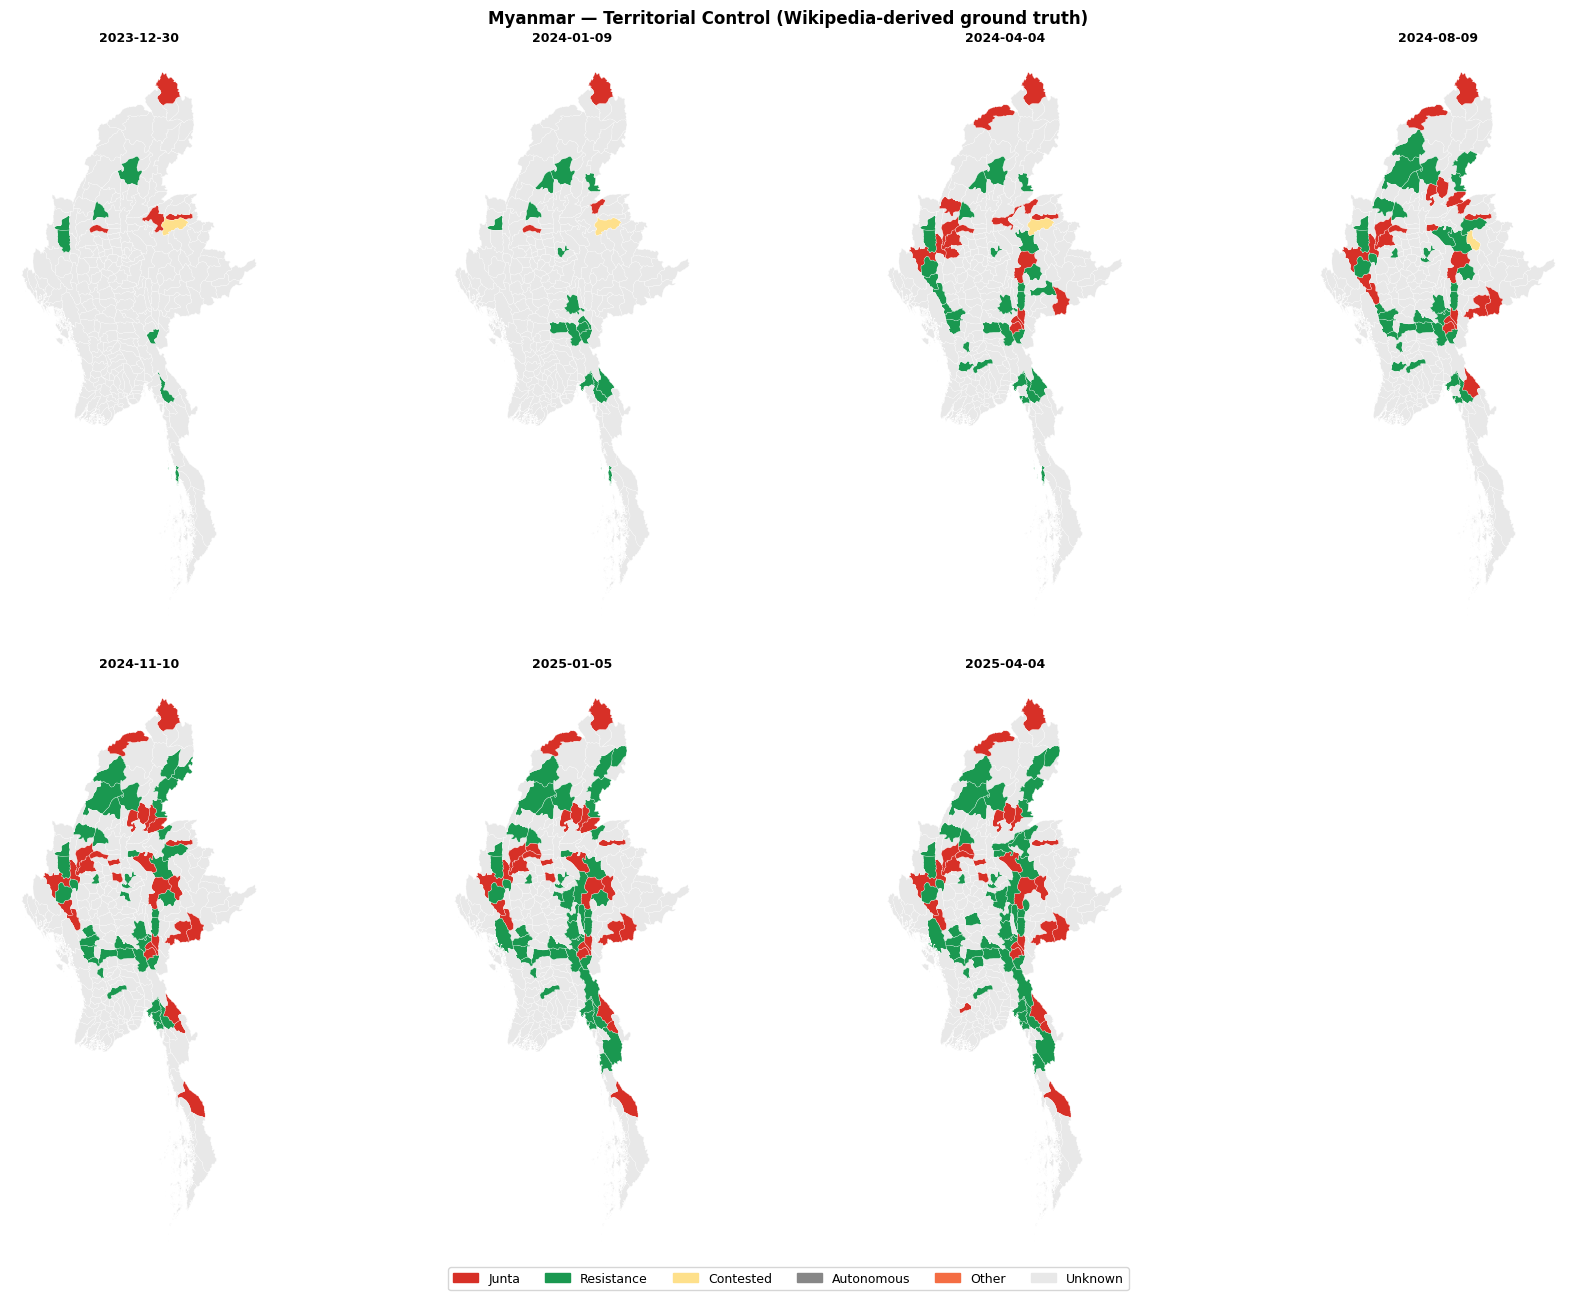

Saved → C:\Users\corne\OneDrive\Nuttige dingen\Verder studeren Spanje\BSE\LEERSTOF\Term3\Thesis\territorial_control_dsdm_master_project\reports\figures\myanmar_wiki_labels.png


In [18]:
BROAD_COLORS = {
    'Junta':      '#d73027',
    'Resistance': '#1a9850',
    'Contested':  '#fee08b',
    'Autonomous': '#878787',
    'Other':      '#f46d43',
    'Unknown':    '#e8e8e8',
}

if 'labels_df' in dir() and len(labels_df) > 0 and gdf is not None:
    dates = sorted(labels_df['date'].unique())
    ncols = min(4, len(dates))
    nrows = -(-len(dates) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.5, nrows*6.5))
    axes = np.array(axes).flatten()

    for i, date in enumerate(dates):
        ax     = axes[i]
        d_data = labels_df[labels_df['date']==date][['township','control_broad']]
        merged = gdf.merge(d_data, on='township', how='left')
        merged['control_broad'] = merged['control_broad'].fillna('Unknown')
        merged['color']         = merged['control_broad'].map(BROAD_COLORS).fillna('#e8e8e8')
        merged.plot(color=merged['color'], ax=ax, edgecolor='white', linewidth=0.2)
        ax.set_title(date, fontsize=9, fontweight='bold', pad=3)
        ax.set_axis_off()

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    patches = [mpatches.Patch(color=v, label=k) for k,v in BROAD_COLORS.items()]
    fig.legend(handles=patches, loc='lower center', ncol=6,
               fontsize=9, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle('Myanmar — Territorial Control (Wikipedia-derived ground truth)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    out = REPO_ROOT / 'reports' / 'figures' / 'myanmar_wiki_labels.png'
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved → {out}")


## Sanity checks

In [19]:
if 'labels_df' in dir() and len(labels_df) > 0:
    checks = [
        ('Naypyidaw',  'Junta capital — always Junta'),
        ('Lashio',     'Captured by MNDAA Aug 2024 — should flip to Resistance'),
        ('Sagaing',    'PDF heartland — Resistance post-2021'),
        ('Ann',        'Captured by Arakan Army Dec 2024 — should flip'),
        ('Myawaddy',   'Karen resistance captured Apr 2024'),
    ]
    for twp, note in checks:
        print(f"--- {twp} ({note}) ---")
        sub = labels_df[labels_df['township'].str.contains(twp, case=False, na=False)]
        if len(sub) == 0:
            # Try district level
            sub = labels_df[labels_df['district'].str.contains(twp, case=False, na=False)]
        if len(sub) == 0:
            print("  Not found\n"); continue
        print(sub[['date','township','control','control_broad']].to_string(index=False))
        print()


--- Naypyidaw (Junta capital — always Junta) ---
  Not found

--- Lashio (Captured by MNDAA Aug 2024 — should flip to Resistance) ---
      date township                  control control_broad
2023-12-30   Lashio                Contested     Contested
2024-01-09   Lashio                Contested     Contested
2024-04-04   Lashio                Contested     Contested
2024-08-09   Lashio Kachin Independence Army    Resistance
2024-11-10   Lashio Kachin Independence Army    Resistance
2025-01-05   Lashio                  Unknown       Unknown
2025-04-04   Lashio                  Unknown       Unknown

--- Sagaing (PDF heartland — Resistance post-2021) ---
      date township  control control_broad
2023-12-30  Sagaing  Unknown       Unknown
2024-01-09  Sagaing  Unknown       Unknown
2024-04-04  Sagaing  Unknown       Unknown
2024-08-09  Sagaing  Unknown       Unknown
2024-11-10  Sagaing Tatmadaw         Junta
2025-01-05  Sagaing Tatmadaw         Junta
2025-04-04  Sagaing Tatmadaw         